# Задача классификации вина по его химическим свойствам

In [1]:
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine(as_frame = True)

X = data.data
X = X[X.columns[:7]]

y = data.target

In [2]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69


In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   alcohol            178 non-null    float64
 1   malic_acid         178 non-null    float64
 2   ash                178 non-null    float64
 3   alcalinity_of_ash  178 non-null    float64
 4   magnesium          178 non-null    float64
 5   total_phenols      178 non-null    float64
 6   flavanoids         178 non-null    float64
dtypes: float64(7)
memory usage: 9.9 KB


In [5]:
# Посмотрим на целевую переменную

y.value_counts()

1    71
0    59
2    48
Name: target, dtype: int64

In [6]:
# Классы не очень сбалансированы, поэтому для оценки качества классификации будем использовать метрику f1-score.
# Разобъем данные на train и test

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [8]:
# Масштабируем данные

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(Xtrain)

Xtrain = pd.DataFrame(scaler.transform(Xtrain), columns = X.columns)
Xtest = pd.DataFrame(scaler.transform(Xtest), columns = X.columns)

In [9]:
# Обучим метод опорных векторов на тренировочных данных и оценим качество на тестовых данных

# Если SVM нужен для задачи классификации, тогда импортируем SVC (support vector classifier)
# Если SVM нужен для задачи классификации, тогда импортируем SVR (support vector regression)

from sklearn.svm import SVC

model = SVC(kernel = 'linear')

model.fit(Xtrain, ytrain)

SVC(kernel='linear')

In [10]:
from sklearn.metrics import f1_score

pred = model.predict(Xtest)

f1_score(ytest, pred, average = 'weighted')

0.8890522875816994

In [12]:
# У SVM как и других линейных моделей есть регуляризация.
# Гиперпараметр С регулирует силу регуляризации. Давайте посмотрим, как меняется качество модели при различных С.

import numpy as np
from sklearn.model_selection import cross_val_score

for C in np.arange(0.01, 1.1, 0.1):
    print('C:', round(C, 2), 'score=', cross_val_score(SVC(kernel = 'linear', C=C), X, y, cv=3, scoring='f1_weighted').mean())

C: 0.01 score= 0.8007977835085888
C: 0.11 score= 0.8813018280615098
C: 0.21 score= 0.8983829315052994
C: 0.31 score= 0.9040271984570724
C: 0.41 score= 0.8981547042711376
C: 0.51 score= 0.9097995167855153
C: 0.61 score= 0.915614786294352
C: 0.71 score= 0.9147587684891816
C: 0.81 score= 0.9203839689175304
C: 0.91 score= 0.9147219225053939
C: 1.01 score= 0.9147219225053939


In [13]:
model = SVC(kernel = 'linear', C = 0.8)

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

f1_score(ytest, pred, average = 'weighted')

0.912826474463303

Также у SVM можно настраивать и другие гиперпараметры:

    class_weight - при сильном дисбалансе классов можно ставить значение 'balanced'

    probability - если требуется предсказывать вероятности классов, то нужно ставить значение True

    decision_function_shape - по умолчанию 'ovr' (для многоклассовой классификации можно пробовать опцию 'ovo')


# Ярдовой метод опорных векторов (Kernel SVM)

In [25]:
!pip install mlxtend --upgrade

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.


In [26]:
from sklearn.svm import SVC
from matplotlib import pyplot as plt
from sklearn.datasets import make_circles, make_moons
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

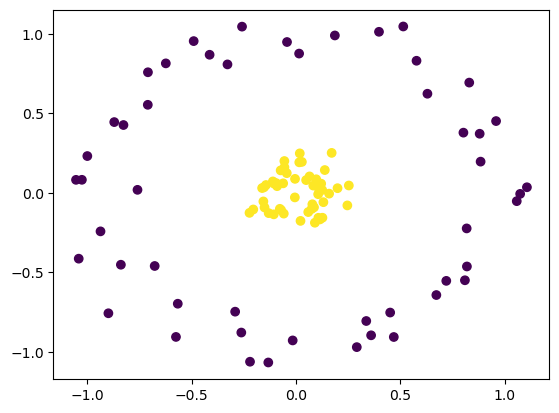

In [28]:
# Сгенерируем две концентрические окружности, точки которых представляют разные классы в задаче бинарной классификации

X, y = make_circles(100, factor = .1, noise = .1)

plt.scatter(X[:, 0], X[:, 1], c = y)

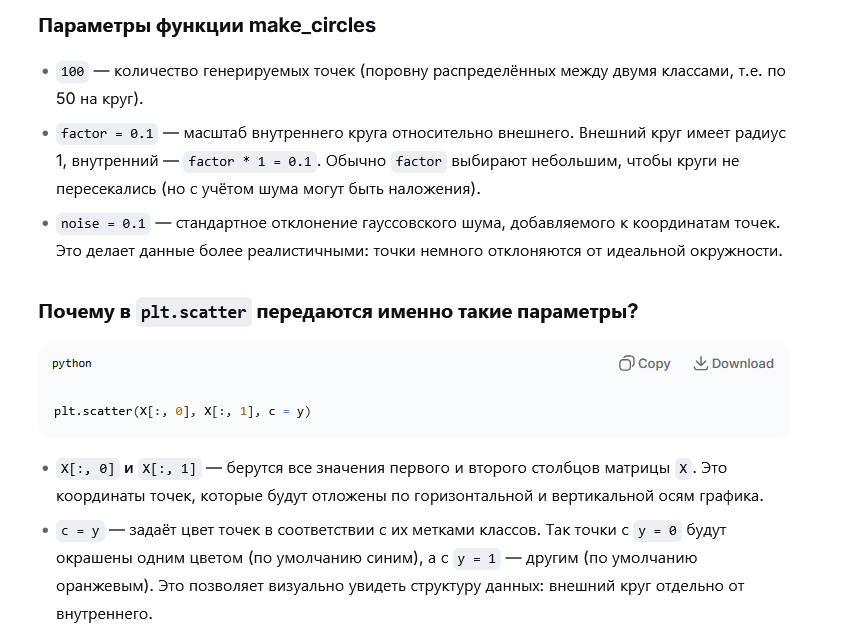

<Axes: >

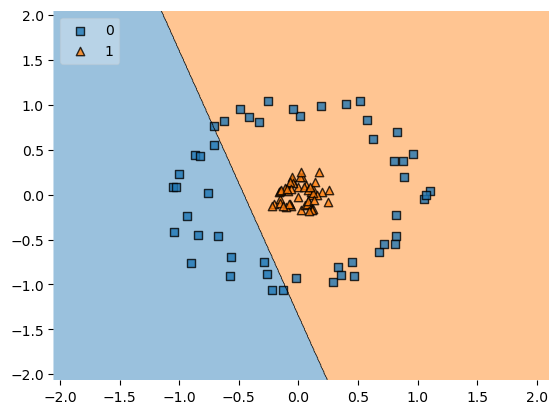

In [31]:
# Построим SVM с линейным ядром

linear_svm = SVC(kernel = 'linear').fit(X, y)
plot_decision_regions(X, y, clf = linear_svm, legend = 2)

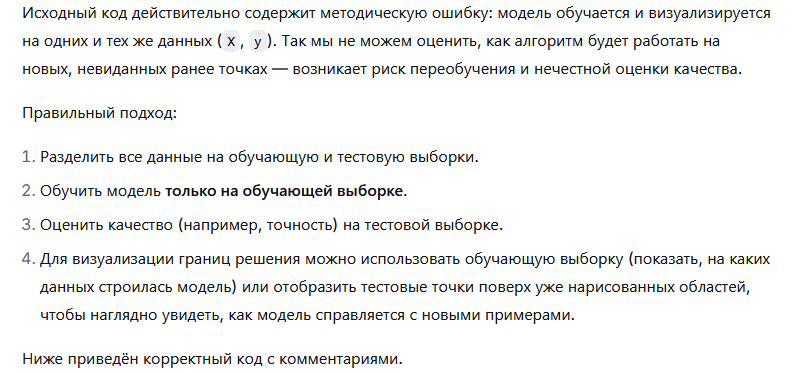

Test accuracy: 0.60


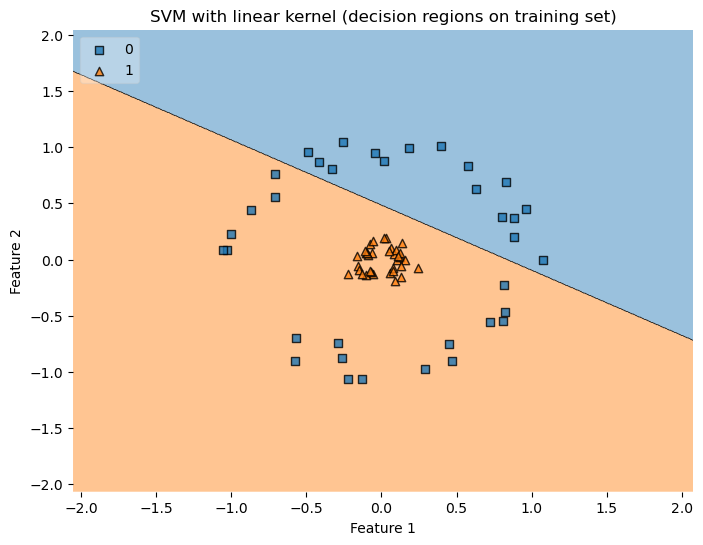

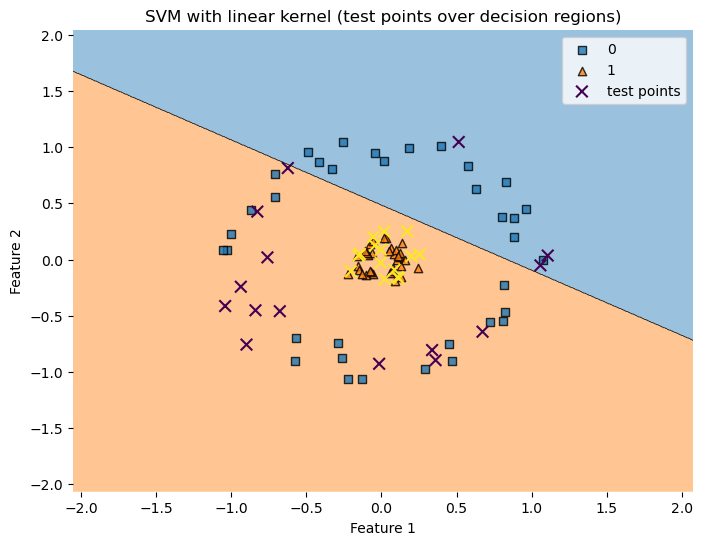

In [32]:
# Необходимые импорты
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

# Генерация данных (из предыдущего шага)
# X, y = make_circles(100, factor=.1, noise=.1)

# 1. Разделяем данные на обучающую и тестовую выборки
#    test_size=0.3 означает, что 30% точек отложим для теста
#    stratify=y сохраняет пропорции классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Обучаем SVM с линейным ядром на тренировочных данных
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

# 3. Оцениваем точность на тесте
accuracy = linear_svm.score(X_test, y_test)
print(f'Test accuracy: {accuracy:.2f}')

# 4. Визуализируем границы решения на основе обучающей выборки
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train, y_train, clf=linear_svm, legend=2)
plt.title('SVM with linear kernel (decision regions on training set)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# 5. Для полноты картины можно отобразить тестовые точки поверх тех же границ
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train, y_train, clf=linear_svm, legend=2)
# Добавляем тестовые точки, помечая их крестиками
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', s=70, 
            cmap='viridis', label='test points')
plt.title('SVM with linear kernel (test points over decision regions)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

<Axes: >

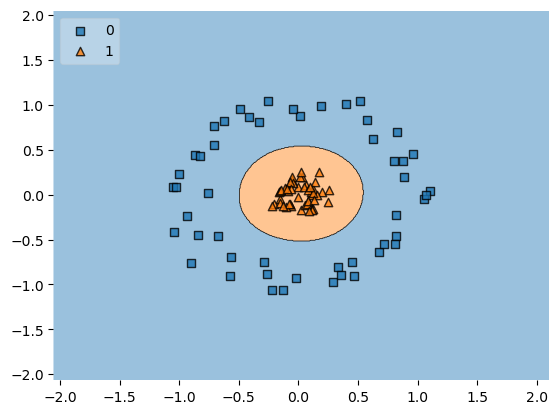

In [33]:
# Построим SVM с радиальным ядром

rbf_svm = SVC(kernel = 'rbf').fit(X, y)
plot_decision_regions(X, y, clf = rbf_svm, legend = 2)

Test accuracy: 1.00


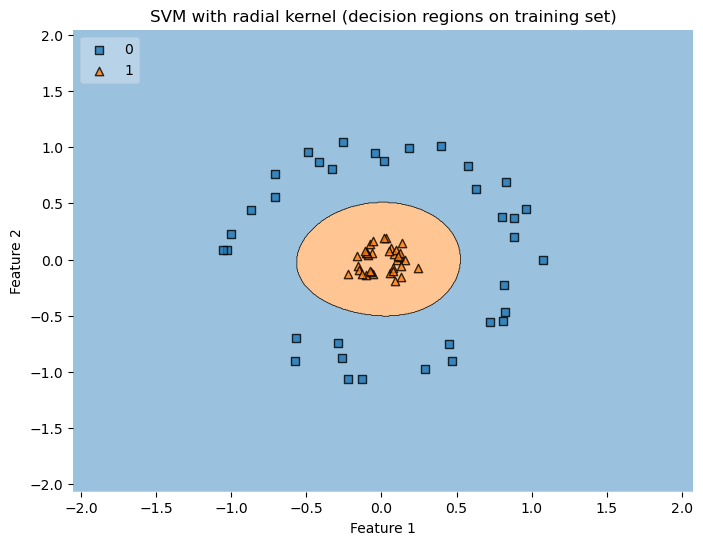

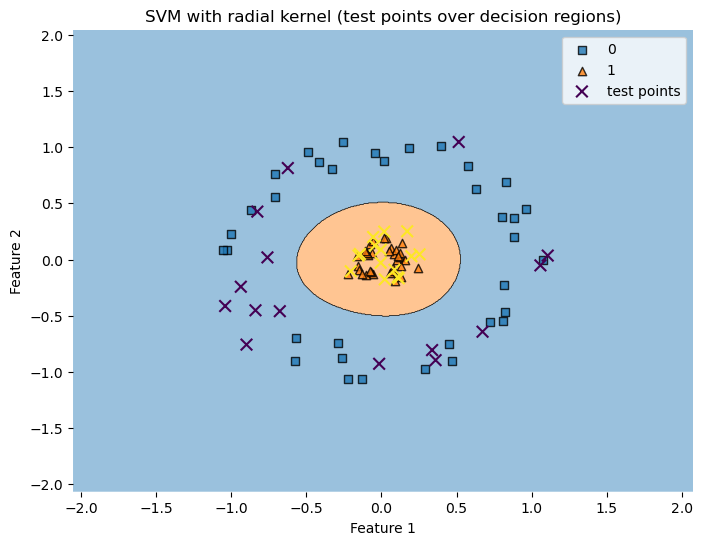

In [34]:
# Необходимые импорты
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

# Генерация данных (из предыдущего шага)
# X, y = make_circles(100, factor=.1, noise=.1)

# 1. Разделяем данные на обучающую и тестовую выборки
#    test_size=0.3 означает, что 30% точек отложим для теста
#    stratify=y сохраняет пропорции классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Обучаем SVM с линейным ядром на тренировочных данных
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)

# 3. Оцениваем точность на тесте
accuracy = rbf_svm.score(X_test, y_test)
print(f'Test accuracy: {accuracy:.2f}')

# 4. Визуализируем границы решения на основе обучающей выборки
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train, y_train, clf=rbf_svm, legend=2)
plt.title('SVM with radial kernel (decision regions on training set)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# 5. Для полноты картины можно отобразить тестовые точки поверх тех же границ
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train, y_train, clf=rbf_svm, legend=2)
# Добавляем тестовые точки, помечая их крестиками
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', s=70, 
            cmap='viridis', label='test points')
plt.title('SVM with radial kernel (test points over decision regions)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

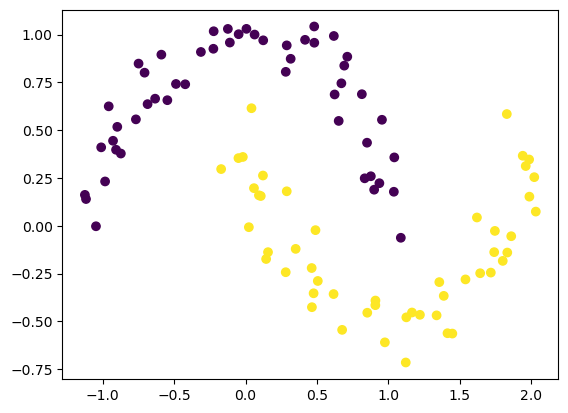

In [35]:
# Сгенерируем две лунки, точки которых представляют разные классы в задаче бинарной классификации

X, y = make_moons(100, noise = .1)

plt.scatter(X[:, 0], X[:, 1], c = y)

<Axes: >

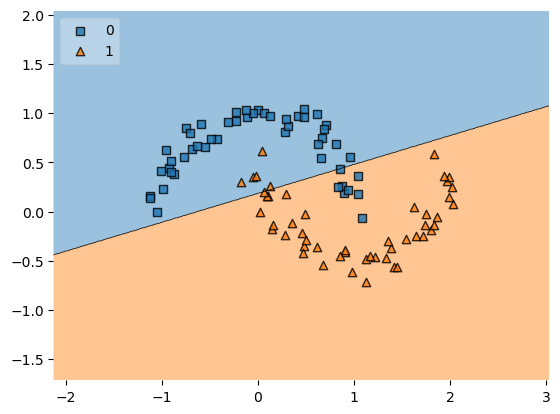

In [36]:
# Построим SVM с линейным ядром

linear_svm = SVC(kernel = 'linear').fit(X, y)
plot_decision_regions(X, y, clf = linear_svm, legend = 2)

<Axes: >

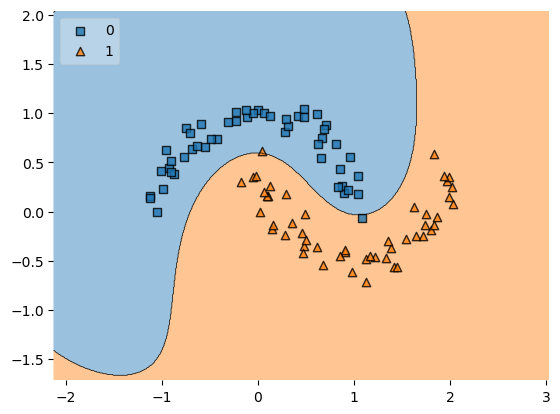

In [37]:
# Построим SVM с радиальным ядром

rbf_svm = SVC(kernel = 'rbf').fit(X, y)
plot_decision_regions(X, y, clf = rbf_svm, legend = 2)

<Axes: >

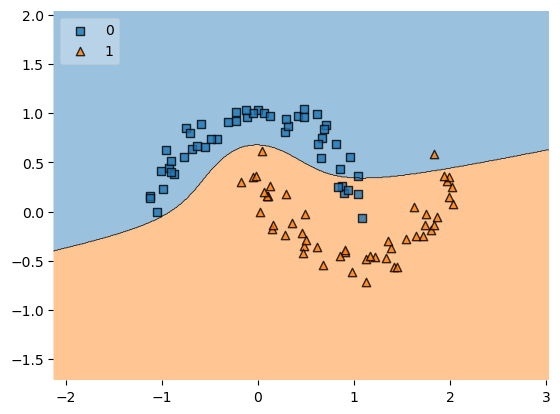

In [38]:
# Построим SVM с полиномиальным ядром

poly_svm = SVC(kernel = 'poly').fit(X, y)
plot_decision_regions(X, y, clf = poly_svm, legend = 2)

<Axes: >

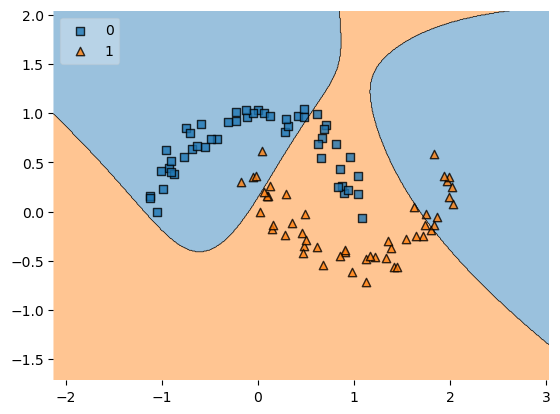

In [39]:
# Построим SVM с сигмоидальным ядром

sigm_svm = SVC(kernel = 'sigmoid').fit(X, y)
plot_decision_regions(X, y, clf = sigm_svm, legend = 2)

# Будем решать задачу классификации вина по его химическим свойствам

In [40]:
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine(as_frame = True)

X = data.data
X = X[X.columns[:7]]

y = data.target

In [45]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69


In [42]:
# Сведем задачу к бинарной классификации: будем определять, является ли вино вином типа 1 или нет

y[y != 1] = 0

y.value_counts()

0    107
1     71
Name: target, dtype: int64

In [43]:
# Разобъем данные на train и test

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [47]:
# Приведем признаки к одному масштабу

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(Xtrain)

Xtrain = pd.DataFrame(scaler.transform(Xtrain), columns = X.columns)
Xtest = pd.DataFrame(scaler.transform(Xtest), columns = X.columns)

In [48]:
# Обучим метод опорных векторов на тренировочных данных и оценим качество на тестовых данных при помощи метрики ROC-AUC.

# Метрика ROC-AUC оперирует в терминах вероятностей, поэтому для ее вычисления алгоритм должен предсказывать вероятности (методом predict_proba).

from sklearn.svm import SVC

model = SVC(kernel = 'linear', probability = True)

model.fit(Xtrain, ytrain)

SVC(kernel='linear', probability=True)

In [49]:
# Для оценки качества будем использовать метрику ROC-AUC

from sklearn.metrics import roc_auc_score

pred = model.predict_proba(Xtest)[:, 1]

roc_auc_score(ytest, pred)

0.9624819624819625

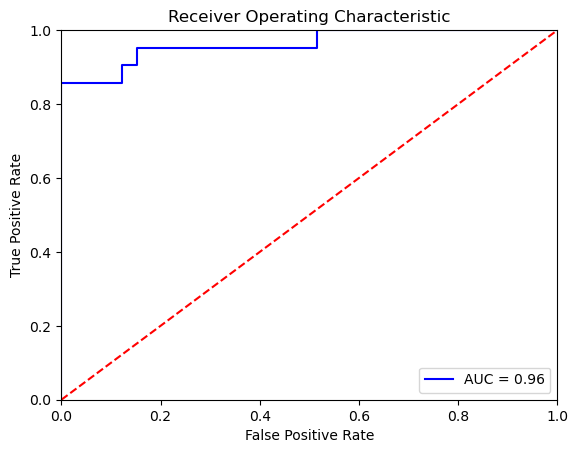

In [50]:
# Построим ROC-кривую

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(ytest, pred)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# SVM. Метод опорных векторов + Кросс-валидация

В этом задании вы попрактикуетесь в применении метода опорных векторов, а также примените кросс-валидацию для подбора гиперпараметров и оценки качества моделей!

## Данные

В этой практической работе мы будем обучать модели машинного обучения, ставить эксперименты, подбирать гиперпараметры и сравнивать модели. Вам предлагается решить задачу бинарной классификации, а именно построить алгоритм, определяющий превысит ли средний заработок человека порог $50k. Каждый объект выборки — человек, для которого известны следующие признаки:
 - `age`
 - `workclass`
 - `fnlwgt`
 - `education`
 - `education-num`
 - `marital-status`
 - `occupation`
 - `relationship`
 - `race`
 - `sex`
 - `capital-gain`
 - `capital-loss`
 - `hours-per-week`

Более подробно про признаки можно почитать [здесь](http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names). Целевой признак записан в переменной *>50K,<=50K*.

## Бонус ноутбука

Все исследователи данных знают, что SVM из библиотеки `sklearn` работает крайне медленно, поэтому на практике не могут его применять для решения задач.

В этом ноутбуке мы используем средства библиотеки `sklearn intelex` для ускорения обучения SVM в 600 раз!

Ради интереса попробуйте после завершения выполнения заданий в ноутбуке удалить ячейки, связанные с установкой и импортом `sklearn intelex` и засечь время работы методов :)

In [1]:
!python --version

Python 3.11.14


In [2]:
%%capture
!python -m pip install --upgrade pip
!pip install --upgrade scikit-learn-intelex

In [1]:
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
import pandas as pd
import numpy as np
import sys
import os
import site
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from matplotlib import pyplot as plt

sys.path.append(os.path.join(os.path.dirname(site.getsitepackages()[0]), "site-packages"))

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/data.adult.csv")

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             16280 non-null  int64
 1   workclass       16280 non-null  str  
 2   fnlwgt          16280 non-null  int64
 3   education       16280 non-null  str  
 4   education-num   16280 non-null  int64
 5   marital-status  16280 non-null  str  
 6   occupation      16280 non-null  str  
 7   relationship    16280 non-null  str  
 8   race            16280 non-null  str  
 9   sex             16280 non-null  str  
 10  capital-gain    16280 non-null  int64
 11  capital-loss    16280 non-null  int64
 12  hours-per-week  16280 non-null  int64
 13  >50K,<=50K      16280 non-null  str  
dtypes: int64(6), str(8)
memory usage: 1.7 MB


In [5]:
df.describe(include = str)

,workclass,education,marital-status,occupation,relationship,race,sex,">50K,<=50K"
count,16280,16280,16280,16280,16280,16280,16280,16280
unique,9,16,7,15,6,5,2,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,<=50K
freq,11282,5214,7552,2095,6618,13912,10919,12244


Иногда в данных встречаются пропуски. Как задаются пропуски обычно либо прописывается в описании к данным, либо просто на месте пропуска после чтения данных оказывается значение `numpy.nan`.  
Более подробно о работе с пропусками в Pandas можно прочитать например [здесь](http://pandas.pydata.org/pandas-docs/stable/missing_data.html).

В данном датасете пропущенные значения обозначены как "?".

In [6]:
# Найдите все признаки, имеющие пропущенные значения.

for cat in df.columns:
    if '?' in df[cat].unique():
        freq = df[cat].value_counts().get('?', 0)
        print(f"В признаке {cat} элемент '?' встречается {freq} раз(а). Процент пропусков = {round(freq / len(df[cat]) * 100, 2)} %")

В признаке workclass элемент '?' встречается 929 раз(а). Процент пропусков = 5.71 %
В признаке occupation элемент '?' встречается 933 раз(а). Процент пропусков = 5.73 %


In [7]:
# Затем удалите из выборки все объекты с пропусками.

df = df[df['workclass'] != '?']
df = df[df['occupation'] != '?']

Обычно после загрузки датасета всегда необходима его некоторая предобработка.
В данном случае она будет заключаться в следующем:

In [8]:
# Выделите целевую переменную y в отдельную переменную и преобразуйте к бинарному формату по правилу:
# '>50K' - 1, '<=50K' - 0.

y = df['>50K,<=50K'].map({'>50K' : 1, '<=50K' : 0})

In [9]:
# Выделите матрицу объект-признак X, содержащую только вещественные столбцы (числовые) и не содержащую целевой переменной

# Обратите внимание, что не все признаки являются вещественными. В начале мы будем работать только с вещественными признаками. Выделите их отдельно.

X = df.select_dtypes(include=['int64'])

In [10]:
X.info()

<class 'pandas.DataFrame'>
Index: 15347 entries, 0 to 16279
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             15347 non-null  int64
 1   fnlwgt          15347 non-null  int64
 2   education-num   15347 non-null  int64
 3   capital-gain    15347 non-null  int64
 4   capital-loss    15347 non-null  int64
 5   hours-per-week  15347 non-null  int64
dtypes: int64(6)
memory usage: 839.3 KB


(array([2466., 2776., 2966., 3066., 1931., 1203.,  667.,  183.,   62.,
          27.]),
 array([17. , 24.3, 31.6, 38.9, 46.2, 53.5, 60.8, 68.1, 75.4, 82.7, 90. ]),
 <BarContainer object of 10 artists>)

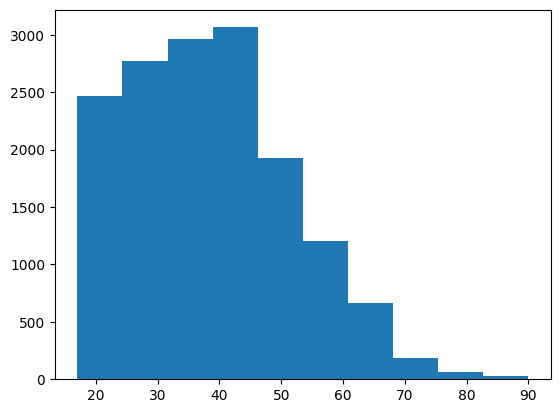

In [11]:
import matplotlib.pyplot as plt

plt.hist(X['age'])

In [78]:
from utils import plot_hist_with_KDE # Питонячий файл с написанными мной функциями

In [77]:
# Когда вносишь изменения в файл utils (меняешь названия функций, добавляешь новые), запускай этот код и все изменения подгрузятся

import importlib
import utils          # импортируем сам модуль (если ещё не импортирован)
importlib.reload(utils)

<module 'utils' from 'C:\\Users\\1\\practical ml\\utils.py'>

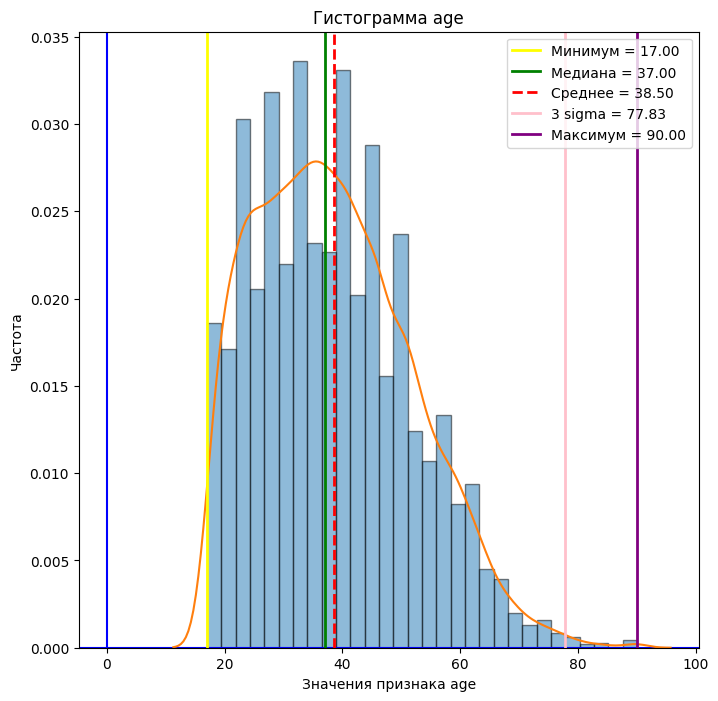

In [13]:
# Построим гистограмму для признака 'age'

plot_hist_with_KDE(X, 'age')

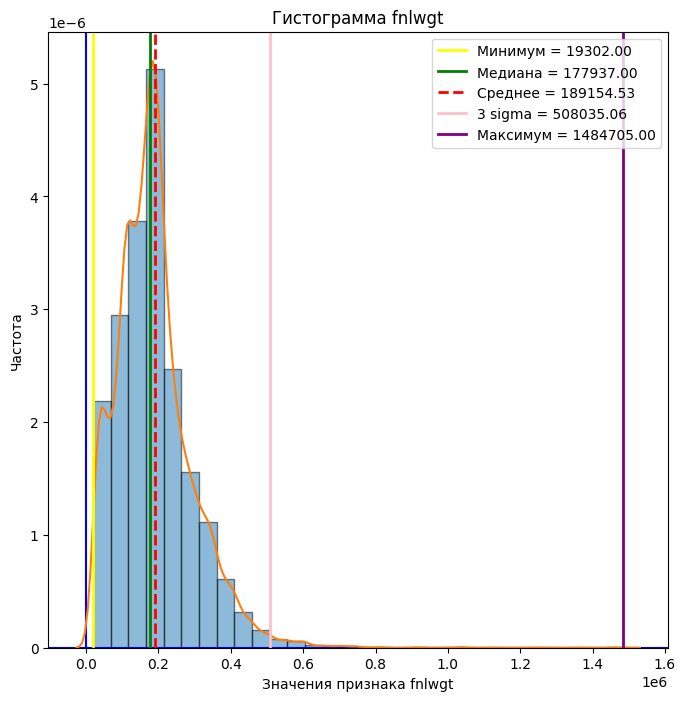

In [14]:
# Построим гистограмму для признака 'fnlwgt'

plot_hist_with_KDE(X, 'fnlwgt')

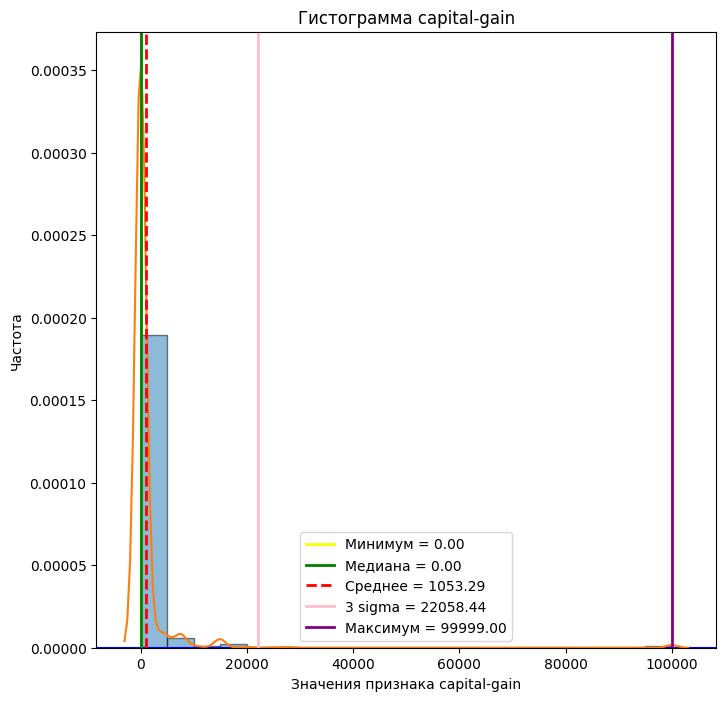

In [15]:
# Построим гистограмму для признака 'capital-gain'

plot_hist_with_KDE(X, 'capital-gain', set_bins=20)

In [16]:
# Стало интересно, почему медиана 0, а среднее не 0

freq = df['capital-gain'].value_counts().get(0.0, 0)
print(f"В признаке capital-gain элемент '0' встречается {freq} раз(а). Процент пропусков = {round(freq / len(df['capital-gain']) * 100, 2)} %")

В признаке capital-gain элемент '0' встречается 14019 раз(а). Процент пропусков = 91.35 %


### Глядя на получившиеся графики в чем заключается особенность данных? 

1) У данных разный масштаб
2) Есть выбросы

### На какие алгоритмы это может повлиять? 

Масштабирование (стандартизация или нормализация) обязательно для алгоритмов, чувствительных к масштабу (kNN, SVM, линейные модели, нейросети). Оно приводит все признаки к единому диапазону, чтобы каждый вносил сопоставимый вклад

### Может ли масшитабирование повлиять на работу этих алгоритмов?

Да

Однако масштабирование не устраняет выбросы – после стандартизации они останутся выбросами, просто в новом масштабе (например, значение 100 000 после стандартизации может стать 20, в то время как основная масса данных лежит в пределах от -2 до 2). Это всё ещё может негативно влиять на модели, чувствительные к выбросам (например, линейные модели с MSE-потерей).

Для смягчения влияния выбросов применяют:

1) Робастное масштабирование (RobustScaler), которое использует медиану и квантили (обычно 1-й и 3-й квартили) – оно менее чувствительно к выбросам.

2) Трансформации признаков (логарифмирование log1p, взятие квадратного корня) – они сжимают длинные хвосты и делают распределение более симметричным. Особенно полезно для capital-gain, где много нулей (можно применить log1p после сдвига).

3) Удаление или ограничение выбросов (например, каппинг на уровне 99-го процентиля), если выбросы являются ошибочными или неинформативными.

Таким образом, ваш вывод «масштабирование решит проблему отчасти (выбросы так и останутся)» совершенно справедлив. Масштабирование – важный, но не единственный шаг предобработки.

In [17]:
# Масштабируйте все вещественные признаки (масштабированную матрицу назовите, как и раньше, X).

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X = pd.DataFrame(scaler.transform(X), columns = X.columns)

### Кросс-валидация [обучающий текст]

Разбивать данные на train-test как мы делали раньше - неплохой подход. Однако при этом подходе мы привязываем и обучение модели, и оценку качества к конкретному разбиению, а для другого разбиения можем получить модель совершенно другого качества, что плохо.

Поэтому хочется оценить качество модели без привязки к конкретному разбиению на train-test. Для этого все обучающие данные разбиваются на несколько равных блоков (фолдов), и затем модель обучается несколько раз:
* первый раз - на всех блоках, кроме 1-го, а качество оценивается на 1-м блоке
* второй раз - на всех блоках, кроме 2-го, а качество оценивается на 2-м блоке и так далее
Для оценки качества модели полученные значения метрик на тестовых блоках усредняются - это называется *k-fold кросс-валидацией*.

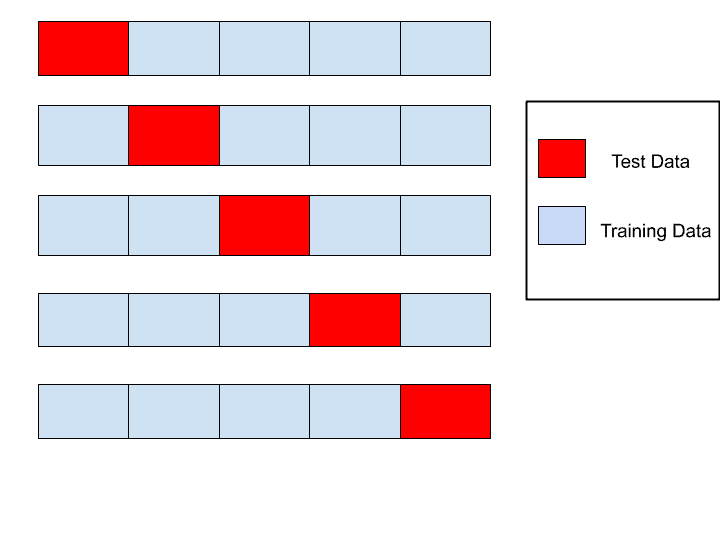

In [18]:
# Обучим по кросс-валидации с тремя фолдами Логистическую Регрессию

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

roc_auc_lr = cross_val_score(LogisticRegression(), X, y, cv = 3, scoring = 'roc_auc', verbose = 2).mean()

roc_auc_svc = cross_val_score(SVC(kernel = 'linear'), X, y, cv = 3, scoring = 'roc_auc', verbose = 2).mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.7s
[CV] END .................................................... total time=   0.4s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.1s finished


In [20]:
# Посмотрим на качество моделей 

print(f'ROC_AUC of Logistic Regression with CV = 3 is {round(roc_auc_lr, 4)}')
print(f'ROC_AUC of SVC with linear kernel with CV = 3 is {round(roc_auc_svc, 4)}')

ROC_AUC of Logistic Regression with CV = 3 is 0.8245
ROC_AUC of SVC with linear kernel with CV = 3 is 0.8059


Теперь посмотрим как влияет подбор гиперпараметров на качество предсказания моделей. Сейчас и далее будем рассматривать два алгоритма:
 - Logistic Regression
 - SVC (Support Vector Classifier)

У обоих алгоритмов будем оптимизировать гиперпараметр С, а у SVC - ещё гиперпараметр kernel.

*  Ищите C в диапазоне от 0.01 до 10.01 с шагом 0.25
*  Перебирайте ядра из списка ['rbf','poly','sigmoid','linear']

### Подбор гиперпараметров по сетке (GridSearchCV) [обучающий текст]

Раз уж мы начали использовать кросс-валидацию, то будем использовать ее по-максимуму. Для подбора гиперпараметров модели также можно применить этот подход вместо разбиения на train и test.

Идея подбора гиперпараметров по сетке:

* задаем список перебираемых значений гиперпараметров (можно подбирать одновременно несколько гиперпараметров)

* для каждого набора значений гиперпараметров вычисляем качество модели по кросс-валидации

* итоговый ответ - это набор значений гиперпараметров, для которого модель имеет наибольшее качество на кросс-валидации.

Метод, реализующий эту схему, называется GridSearchCV.

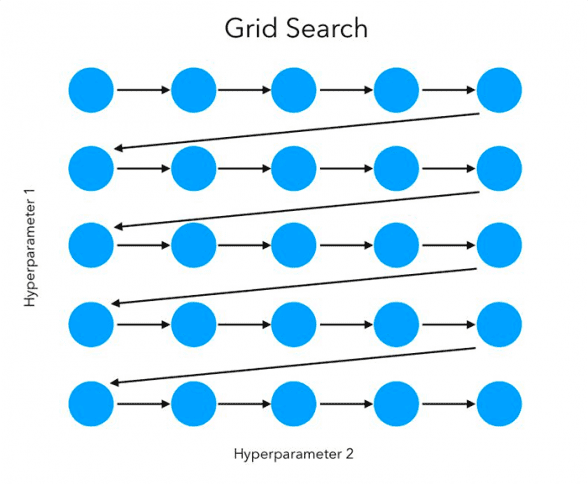

Для подбора гиперпараметров воспользуйтесь перебором по сетке, который реализован в классе GridSearchCV. В качестве схемы кросс-валидации используйте 3-fold cv.

Покажем пример использования GridSearchCV.

In [21]:
# Подберем гиперпараметр C (в диапазоне от 0.01 до 10.01 с шагом 0.25) у Логистической Pегрессии

from sklearn.model_selection import GridSearchCV

params = {'C' : np.arange(0.01, 10.01, 0.25)} # задаем словарь параметров и список перебираемых значений

gs = GridSearchCV(LogisticRegression(), params, cv = 3, scoring = 'roc_auc')
# первый параметр - модель, второй - словарь параметров, третий - число фолдов, четвертый - метрика

gs.fit(X, y) # применяем метод к данным X, y (GridSearchCV сам разобъет данные на фолды)

print(gs.best_score_) # качество наилучшей модели (с оптимальными гиперпараметрами)
print(gs.best_params_) # оптимальные гиперпараметры

0.8249643365869496
{'C': np.float64(0.51)}


In [22]:
# так как SVM работает долго, то:
# сначала первым gridsearch подберите у метода только kernel
# вторым gridsearch для найденного ядра подберите C в диапазане от 0.01 до 2.01 с шагом 0.25

# Шаг 1: подбор ядра SVC

params = {'kernel' : ['rbf','poly','sigmoid','linear']} 

gs = GridSearchCV(SVC(), params, cv = 3, scoring = 'roc_auc', verbose=3)

gs.fit(X, y) 

print(gs.best_score_) 
print(gs.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 1/3] END ........................kernel=rbf;, score=0.810 total time=   0.4s
[CV 2/3] END ........................kernel=rbf;, score=0.805 total time=   0.4s
[CV 3/3] END ........................kernel=rbf;, score=0.802 total time=   0.4s
[CV 1/3] END .......................kernel=poly;, score=0.800 total time=   0.6s
[CV 2/3] END .......................kernel=poly;, score=0.794 total time=   0.7s
[CV 3/3] END .......................kernel=poly;, score=0.801 total time=   0.8s
[CV 1/3] END ....................kernel=sigmoid;, score=0.666 total time=   0.2s
[CV 2/3] END ....................kernel=sigmoid;, score=0.679 total time=   0.2s
[CV 3/3] END ....................kernel=sigmoid;, score=0.670 total time=   0.3s
[CV 1/3] END .....................kernel=linear;, score=0.810 total time=   0.8s
[CV 2/3] END .....................kernel=linear;, score=0.809 total time=   0.7s
[CV 3/3] END .....................kernel=linear;,

In [23]:
# Шаг 2: подбор С

params = {'C' : np.arange(0.01, 10.01, 0.25)}

gs = GridSearchCV(SVC(kernel = 'linear'), params, cv = 3, scoring = 'roc_auc', verbose=3)

gs.fit(X, y) 

print(gs.best_score_) 
print(gs.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV 1/3] END ............................C=0.01;, score=0.813 total time=   0.2s
[CV 2/3] END ............................C=0.01;, score=0.812 total time=   0.2s
[CV 3/3] END ............................C=0.01;, score=0.809 total time=   0.2s
[CV 1/3] END ............................C=0.26;, score=0.810 total time=   0.4s
[CV 2/3] END ............................C=0.26;, score=0.809 total time=   0.4s
[CV 3/3] END ............................C=0.26;, score=0.808 total time=   0.2s
[CV 1/3] END ............................C=0.51;, score=0.810 total time=   0.6s
[CV 2/3] END ............................C=0.51;, score=0.809 total time=   0.4s
[CV 3/3] END ............................C=0.51;, score=0.801 total time=   0.3s
[CV 1/3] END ............................C=0.76;, score=0.810 total time=   0.7s
[CV 2/3] END ............................C=0.76;, score=0.809 total time=   0.5s
[CV 3/3] END ............................C=0.76

# Добавляем категориальные признаки в модель

Пока мы не использовали нечисловые признаки, которые есть в датасете. Давайте посмотрим, правильно ли мы сделали и увеличится ли качество моделей после добавлениях этих признаков.

*  Преобразуйте все категориальные признаки (исходной матрицы df) с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [`pandas.get_dummies`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html). Чтобы избежать переобучения, в `get_dummies` поставьте гиперпараметр **`drop_first=True`**.

*  Заново масштабируйте данные

In [61]:
# Создаем таблицу со всеми признаками

X_old = df.drop('>50K,<=50K', axis = 1)

In [62]:
X_old.info()

<class 'pandas.DataFrame'>
Index: 15347 entries, 0 to 16279
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             15347 non-null  int64
 1   workclass       15347 non-null  str  
 2   fnlwgt          15347 non-null  int64
 3   education       15347 non-null  str  
 4   education-num   15347 non-null  int64
 5   marital-status  15347 non-null  str  
 6   occupation      15347 non-null  str  
 7   relationship    15347 non-null  str  
 8   race            15347 non-null  str  
 9   sex             15347 non-null  str  
 10  capital-gain    15347 non-null  int64
 11  capital-loss    15347 non-null  int64
 12  hours-per-week  15347 non-null  int64
dtypes: int64(6), str(7)
memory usage: 1.6 MB


In [63]:
# Кодируем категориальные признаки с помощью OHE

import pandas as pd

# Выбираем только категориальные столбцы (тип 'str')
cat_cols = X_old.select_dtypes(include=['str']).columns

# Применяем one-hot кодирование с удалением первого уровня (чтобы избежать дамми-ловушки)
X_encoded = pd.get_dummies(X_old, columns=cat_cols, drop_first=True)

In [64]:
# Заново масштабируйте признаки

scaler = StandardScaler()
scaler.fit(X_encoded)
X_encoded = pd.DataFrame(scaler.transform(X_encoded), columns = X_encoded.columns)

In [65]:
# Обучите алгоритмы с наилучшими гиперпараметрами из предыдущего пункта. 
# Дало ли добавление новых признаков прирост качества?
# Измеряйте качество как и раньше используя 3-Fold CV в функции cross_val_score.

best_lr_C = 0.51

best_SVC_kernel = 'linear'
best_SVC_C = 0.01

roc_auc_lr1 = cross_val_score(LogisticRegression(C = best_lr_C), X_encoded, y, cv = 3, scoring = 'roc_auc', verbose = 2).mean()

roc_auc_svc1 = cross_val_score(SVC(C = best_SVC_C, kernel = best_SVC_kernel), X_encoded, y, cv = 3, scoring = 'roc_auc', verbose = 2).mean()

# Посмотрим на качество моделей 

print(f'ROC_AUC of Logistic Regression with CV = 3 is {round(roc_auc_lr1, 4)}')
print(f'ROC_AUC of SVC with linear kernel with CV = 3 is {round(roc_auc_svc1, 4)}')

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
ROC_AUC of Logistic Regression with CV = 3 is 0.9027
ROC_AUC of SVC with linear kernel with CV = 3 is 0.8982


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.9s finished


In [66]:
# Разбейте данные (после OneHot-кодировки) на тренировочную и тестовую часть 

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X_encoded, y, test_size=0.25, random_state=42)

In [67]:
# Заново масштабируйте признаки

scaler = StandardScaler()
scaler.fit(Xtrain)

Xtrain = pd.DataFrame(scaler.transform(Xtrain), columns = Xtrain.columns)
Xtest = pd.DataFrame(scaler.transform(Xtest), columns = Xtest.columns)

In [70]:
ytest

4475     0
1889     0
9566     0
15297    0
3995     0
        ..
3411     0
144      1
9211     0
4794     0
14685    0
Name: >50K,<=50K, Length: 3837, dtype: int64

In [72]:
# Cреди всех обученных в работе моделей возьмите наилучшую (по roc-auc). 
# Заново обучите эту модель на тренировочных данных, сделайте предсказание на тесте

# Чему равен roc-auc наилучшей модели на тестовых данных?


from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

model = SVC(C = best_SVC_C, kernel = best_SVC_kernel, probability = True)

model.fit(Xtrain, ytrain)

pred = model.predict_proba(Xtest.values)[:, 1]

print(f'ROC_AUC of SVC with linear kernel on test is {round(roc_auc_score(ytest, pred), 4)}')

ROC_AUC of SVC with linear kernel on test is 0.8996


In [74]:
from utils import plot_roc_curve_with_auc

# Построим ROC-кривую

plot_roc_curve_with_auc(ytest, pred)

ImportError: cannot import name 'plot_roc_curve_with_auc' from 'utils' (C:\Users\1\practical ml\utils.py)